In [766]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [767]:
training_data = pd.read_csv('./dataset/train.csv')
test_data = pd.read_csv('./dataset/test.csv')

In [768]:
print(training_data.shape)
print(test_data.shape)

(891, 12)
(418, 11)


In [769]:
training_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [770]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# check the data balance

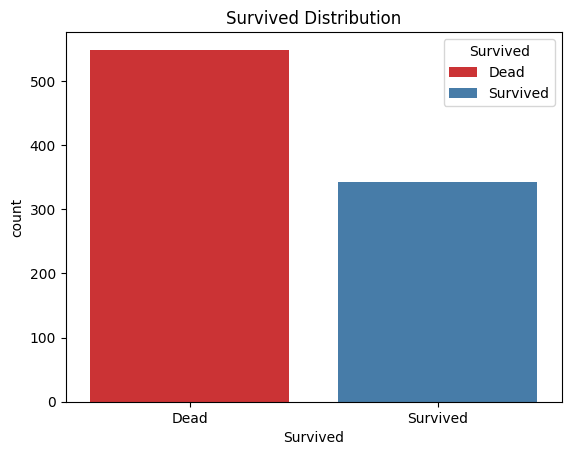

In [771]:
# The first chart shows that more passengers died than survived.
sns.countplot(x='Survived', data=training_data, hue='Survived', palette='Set1')
plt.title('Survived Distribution')
plt.xticks([0,1], ['Dead', 'Survived'])
plt.legend(title='Survived', labels=['Dead', 'Survived'])
plt.show()

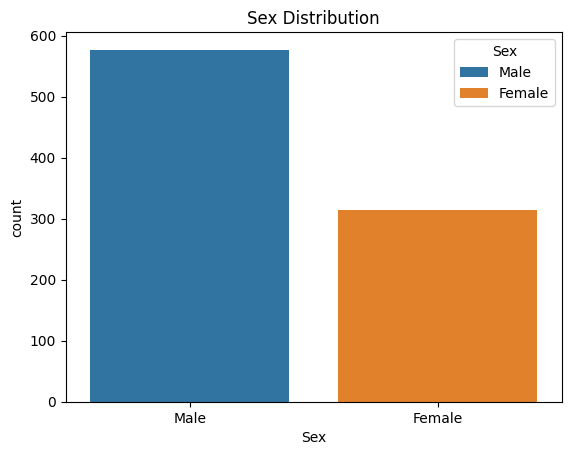

In [772]:
# The second chart shows that there were more male passengers than female passengers. 
sns.countplot(x='Sex', data=training_data, hue='Sex')
plt.title('Sex Distribution')
plt.xticks([0,1], ['Male', 'Female'])
plt.legend(title='Sex', labels=['Male', 'Female'])
plt.show()


# feature analysis

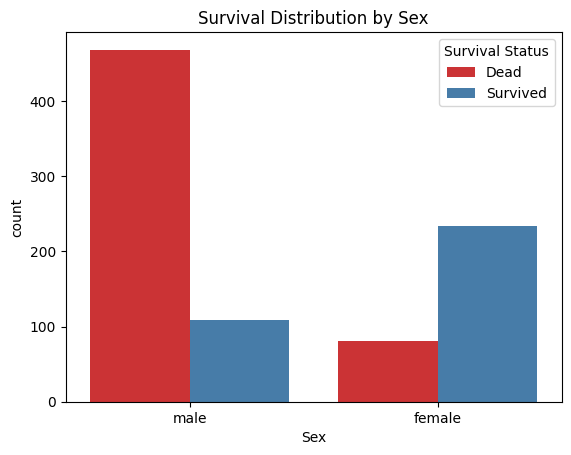

In [773]:
#The third chart shows that most men died, but many women survived.So,Sex is an important feature.
sns.countplot(x='Sex', data=training_data, hue='Survived', palette='Set1')
plt.title('Survival Distribution by Sex')
plt.legend(title='Survival Status', labels=['Dead', 'Survived'])
plt.show()

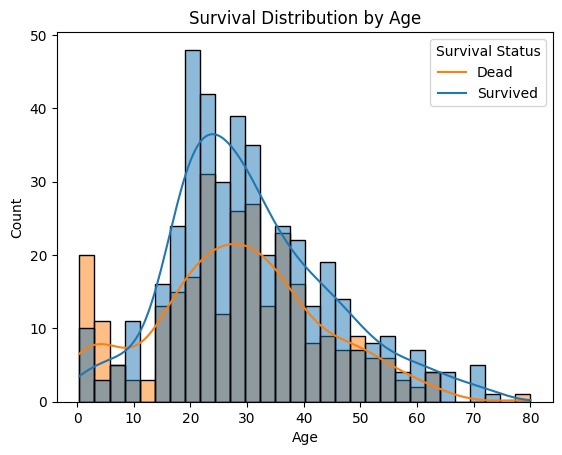

In [774]:
# The Age chart shows that most passengers were between 20 and 40 years old.
sns.histplot(x='Age', data=training_data, hue='Survived', bins=30, kde=True)
plt.title('Survival Distribution by Age')
plt.legend(title='Survival Status', labels=['Dead', 'Survived'])
plt.show()

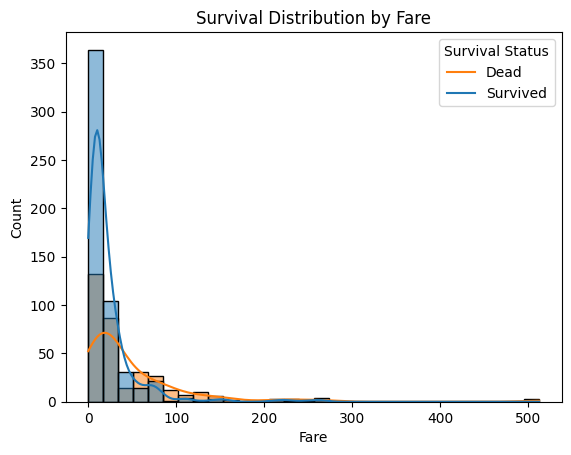

In [775]:
# The Fare chart shows that most passengers paid low fares, but passengers with higher fares had a better survival chance.
sns.histplot(x='Fare', data=training_data, hue='Survived', bins=30, kde=True)
plt.title('Survival Distribution by Fare')
plt.legend(title='Survival Status', labels=['Dead', 'Survived'])
plt.show()

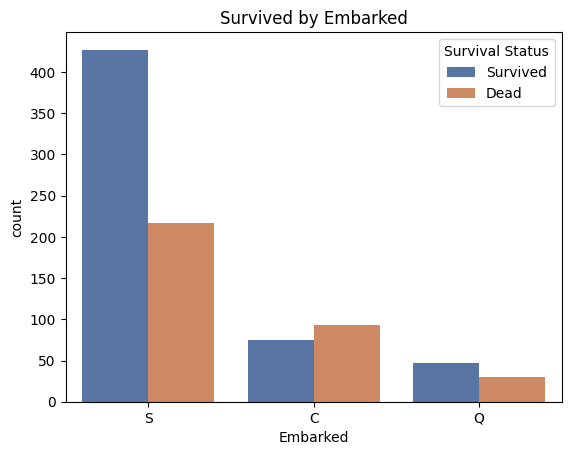

In [776]:
# Most passengers boarded from Southampton.Cherbourg passengers had the best survival rate.Queenstown had fewer passengers than Southampton.
sns.countplot(x='Embarked', data=training_data, hue='Survived', palette='deep')
plt.title('Survived by Embarked')
plt.legend(title='Survival Status', labels=['Survived', 'Dead'])
plt.show()

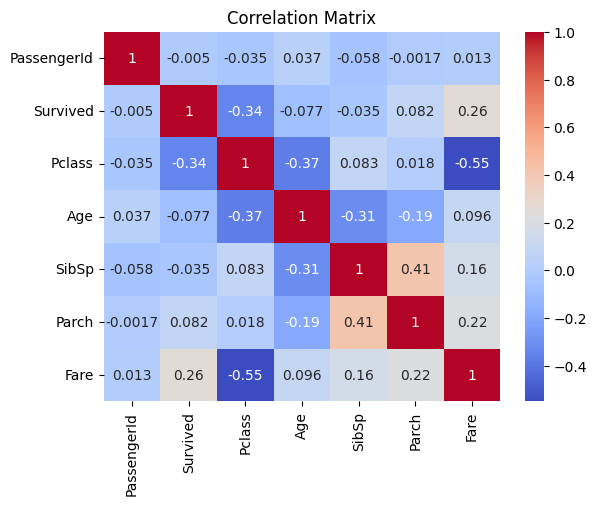

In [777]:
# correlation Matrix
correlation_matrix = training_data.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# data cleaning

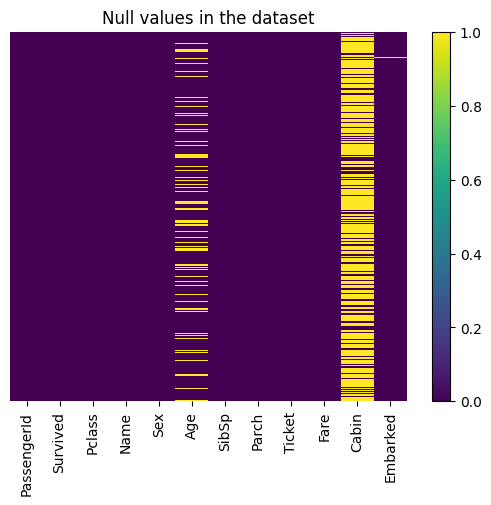

In [778]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()

In [779]:
# we drop the Cabin column because it has too many missing values
training_data = training_data.drop('Cabin', axis=1)
test_data = test_data.drop('Cabin', axis=1)

In [780]:
# for age column, we fill the missing values with the median of the age column
training_data['Age'] = training_data['Age'].fillna(training_data['Age'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())

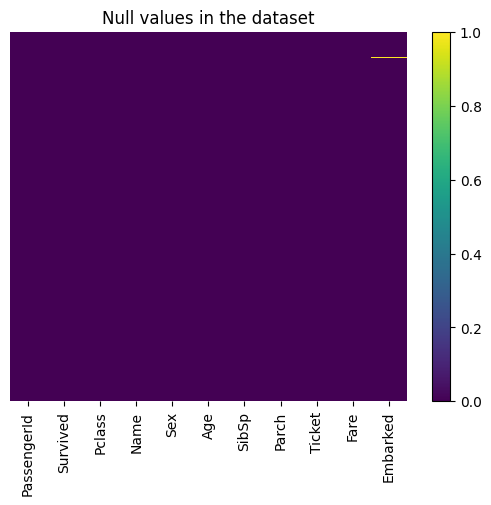

In [781]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()

In [782]:
# fill missing values in the embarked column with the mode of the embarked column
training_data['Embarked'] = training_data['Embarked'].fillna(training_data['Embarked'].mode()[0])
test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

In [783]:
training_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

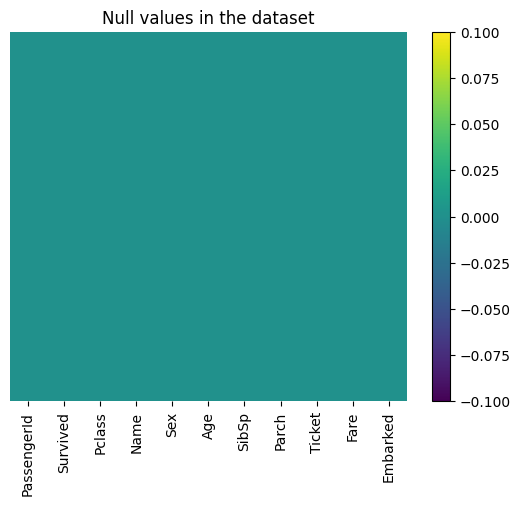

In [784]:
ax = sns.heatmap(training_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
ax.set_title('Null values in the dataset')
ax.figure.colorbar(ax.collections[0])
plt.show()

## categorical to numerical transformation

In [785]:
# drop the Name, Ticket and PassengerId
training_data.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)
test_data.drop(['Name','Ticket','PassengerId'], axis=1, inplace=True)

In [786]:
# encode categorical features
training_data['Sex'] = training_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

In [787]:
# one-hot encoding to Embarked column
training_data = pd.get_dummies(training_data, columns=['Embarked'], drop_first=False, dtype=int)
test_data = pd.get_dummies(test_data, columns=['Embarked'], drop_first=False, dtype=int)
training_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


In [788]:
# training_data['Embarked_C'] = training_data['Embarked_C'].map({True: 1, False: 0})
# training_data['Embarked_Q'] = training_data['Embarked_Q'].map({True: 1, False: 0})
# training_data['Embarked_S'] = training_data['Embarked_S'].map({True: 1, False: 0})
# training_data.head()

In [789]:
# combining SibSp and Parch
training_data['FamilySize'] = training_data['SibSp'] + training_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
training_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,0,3,0,22.0,1,0,7.2500,0,0,1,2
1,1,1,1,38.0,1,0,71.2833,1,0,0,2
2,1,3,1,26.0,0,0,7.9250,0,0,1,1
3,1,1,1,35.0,1,0,53.1000,0,0,1,2
4,0,3,0,35.0,0,0,8.0500,0,0,1,1


In [790]:
# del SibSp and Parch column
training_data = training_data.drop(['SibSp', 'Parch'], axis=1)
test_data = test_data.drop(['SibSp', 'Parch'], axis=1)
training_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,0,3,0,22.0,7.2500,0,0,1,2
1,1,1,1,38.0,71.2833,1,0,0,2
2,1,3,1,26.0,7.9250,0,0,1,1
3,1,1,1,35.0,53.1000,0,0,1,2
4,0,3,0,35.0,8.0500,0,0,1,1


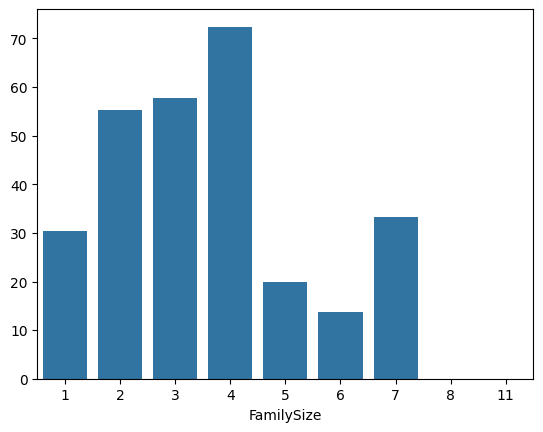

In [791]:
# data ro bar asase family goroup bandi mikone bad mean survivedo dar har gorouh migire * 100 mikone.
perce_survival = training_data.groupby("FamilySize")["Survived"].mean()*100 
sns.barplot(x=perce_survival.index, y=perce_survival.values)
plt.show()

## Train/ Validation split

In [792]:
from sklearn.model_selection import train_test_split

In [793]:
training_features = training_data.drop(['Survived'], axis=1)
training_labels = training_data['Survived']

In [794]:
training_labels.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [795]:
training_features.head()

,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,3,0,22.0,7.2500,0,0,1,2
1,1,1,38.0,71.2833,1,0,0,2
2,3,1,26.0,7.9250,0,0,1,1
3,1,1,35.0,53.1000,0,0,1,2
4,3,0,35.0,8.0500,0,0,1,1


In [796]:
test_data.head()

,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,3,0,34.5,7.8292,0,1,0,1
1,3,1,47.0,7.0000,0,0,1,2
2,2,0,62.0,9.6875,0,1,0,1
3,3,0,27.0,8.6625,0,0,1,1
4,3,1,22.0,12.2875,0,0,1,3


In [797]:
X_train, X_test, y_train, y_test = train_test_split(training_features, training_labels, test_size=0.2)

In [798]:
print(f'X_train shape: {X_train.shape} - X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape} - y_test shape: {y_test.shape}')

X_train shape: (712, 8) - X_test shape: (179, 8)
y_train shape: (712,) - y_test shape: (179,)


# pre-processing

In [799]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [800]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [801]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluation_metrics(y_train, y_pred_train, y_test, y_pred_test):
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    print(f'Accuracy Train: {accuracy_train}')
    print(f'Accuracy Test: {accuracy_test}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1_Score:{f1}')

    print('\nConfusion_Matrix:')
    print(confusion_matrix(y_test, y_pred_test))
    
    print('\nClassification_Report:')
    print(classification_report(y_test, y_pred_test))
    
    return accuracy_train, accuracy_test, precision, recall, f1

## Model training

## 1. Logistic Regression

In [802]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr = lr.predict(X_test)

accuracy_train_lr, accuracy_test_lr, precision_lr, recall_lr, f1_lr = evaluation_metrics(y_train, y_pred_train_lr, y_test, y_pred_test_lr)

Accuracy Train: 0.7963483146067416
Accuracy Test: 0.8324022346368715
Precision: 0.8153846153846154
Recall: 0.7464788732394366
F1_Score:0.7794117647058824

Confusion_Matrix:
[[96 12]
 [18 53]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       108
           1       0.82      0.75      0.78        71

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



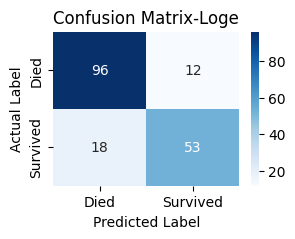

In [803]:
cm = confusion_matrix(y_test, y_pred_test_lr)
plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True, fmt ='d', cmap='Blues', xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix-Loge')
plt.show()

## 2. SVM

In [804]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)
y_pred_train_svm = svm.predict(X_train)
y_pred_test_svm = svm.predict(X_test)

accuracy_train_svm, accuracy_test_svm, precision_svm, recall_svm, f1_svm = evaluation_metrics(y_train, y_pred_train_svm, y_test, y_pred_test_svm)

Accuracy Train: 0.8258426966292135
Accuracy Test: 0.8603351955307262
Precision: 0.9423076923076923
Recall: 0.6901408450704225
F1_Score:0.7967479674796748

Confusion_Matrix:
[[105   3]
 [ 22  49]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89       108
           1       0.94      0.69      0.80        71

    accuracy                           0.86       179
   macro avg       0.88      0.83      0.85       179
weighted avg       0.87      0.86      0.86       179



## 3.KNN

In [805]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors= 17, weights='uniform', metric='euclidean')
knn.fit(X_train, y_train)
y_pred_train_knn = knn.predict(X_train)
y_pred_test_knn = knn.predict(X_test)

accuracy_train_knn, accuracy_test_knn, precision_knn, recall_knn, f1_knn = evaluation_metrics(y_train, y_pred_train_knn, y_test, y_pred_test_knn)

Accuracy Train: 0.8174157303370787
Accuracy Test: 0.8659217877094972
Precision: 0.9122807017543859
Recall: 0.7323943661971831
F1_Score:0.8125

Confusion_Matrix:
[[103   5]
 [ 19  52]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.90       108
           1       0.91      0.73      0.81        71

    accuracy                           0.87       179
   macro avg       0.88      0.84      0.85       179
weighted avg       0.87      0.87      0.86       179



## 4. Random Forest

In [806]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, max_features='sqrt')
rf.fit(X_train, y_train)
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)

accuracy_train_rf, accuracy_test_rf, precision_rf, recall_rf, f1_rf = evaluation_metrics(y_train, y_pred_train_rf, y_test, y_pred_test_rf)

Accuracy Train: 0.8455056179775281
Accuracy Test: 0.8715083798882681
Precision: 0.9444444444444444
Recall: 0.7183098591549296
F1_Score:0.816

Confusion_Matrix:
[[105   3]
 [ 20  51]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       108
           1       0.94      0.72      0.82        71

    accuracy                           0.87       179
   macro avg       0.89      0.85      0.86       179
weighted avg       0.88      0.87      0.87       179



## 5. ANN

In [807]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=50, max_iter=600, activation='relu', solver='adam')
mlp.fit(X_train, y_train)
y_pred_train_mlp = rf.predict(X_train)
y_pred_test_mlp = rf.predict(X_test)

accuracy_train_mlp, accuracy_test_mlp, precision_mlp, recall_mlp, f1_mlp = evaluation_metrics(y_train, y_pred_train_mlp, y_test, y_pred_test_mlp)

Accuracy Train: 0.8455056179775281
Accuracy Test: 0.8715083798882681
Precision: 0.9444444444444444
Recall: 0.7183098591549296
F1_Score:0.816

Confusion_Matrix:
[[105   3]
 [ 20  51]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       108
           1       0.94      0.72      0.82        71

    accuracy                           0.87       179
   macro avg       0.89      0.85      0.86       179
weighted avg       0.88      0.87      0.87       179



## 6. Decision Tree

In [808]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth= 5, min_samples_leaf=4, min_samples_split=10)
dt.fit(X_train, y_train)
y_pred_train_dt = rf.predict(X_train)
y_pred_test_dt = rf.predict(X_test)

accuracy_train_dt, accuracy_test_dt, precision_dt, recall_dt, f1_dt = evaluation_metrics(y_train, y_pred_train_dt, y_test, y_pred_test_dt)

Accuracy Train: 0.8455056179775281
Accuracy Test: 0.8715083798882681
Precision: 0.9444444444444444
Recall: 0.7183098591549296
F1_Score:0.816

Confusion_Matrix:
[[105   3]
 [ 20  51]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       108
           1       0.94      0.72      0.82        71

    accuracy                           0.87       179
   macro avg       0.89      0.85      0.86       179
weighted avg       0.88      0.87      0.87       179



## 7. GaussianNB

In [809]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_train_nb = nb.predict(X_train)
y_pred_test_nb = nb.predict(X_test)

accuracy_train_nb, accuracy_test_nb, precision_nb, recall_nb, f1_nb = evaluation_metrics(y_train, y_pred_train_nb, y_test, y_pred_test_nb)

Accuracy Train: 0.7893258426966292
Accuracy Test: 0.8324022346368715
Precision: 0.847457627118644
Recall: 0.704225352112676
F1_Score:0.7692307692307693

Confusion_Matrix:
[[99  9]
 [21 50]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       108
           1       0.85      0.70      0.77        71

    accuracy                           0.83       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



## Model Performance Comparison

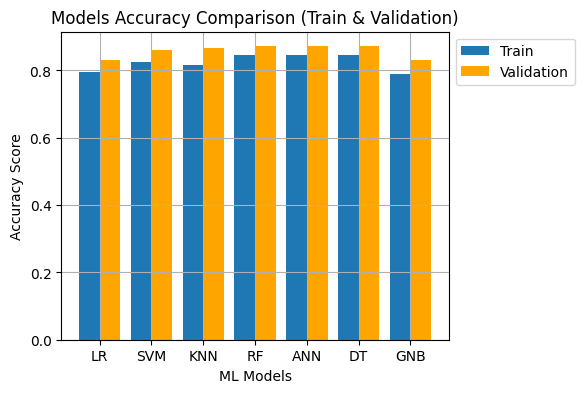

In [810]:
models = ['LR', 'SVM', 'KNN', 'RF','ANN','DT','GNB']
accuracy_train = [accuracy_train_lr,accuracy_train_svm,accuracy_train_knn,accuracy_train_rf,accuracy_train_mlp,accuracy_train_dt,accuracy_train_nb]
accuracy_test = [accuracy_test_lr,accuracy_test_svm,accuracy_test_knn,accuracy_test_rf,accuracy_test_mlp,accuracy_test_dt,accuracy_test_nb]

plt.figure(figsize=(5,4))
x = np.arange(len(models))
plt.bar(x, accuracy_train, width=0.4, label="Train")
plt.bar(x + 0.4, accuracy_test, width=0.4, label="Validation", color="orange")
plt.xticks(x + 0.2, models)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.title('Models Accuracy Comparison (Train & Validation)')
plt.xlabel("ML Models")
plt.ylabel('Accuracy Score')
plt.grid()
plt.show()

## F1 Score Comparison

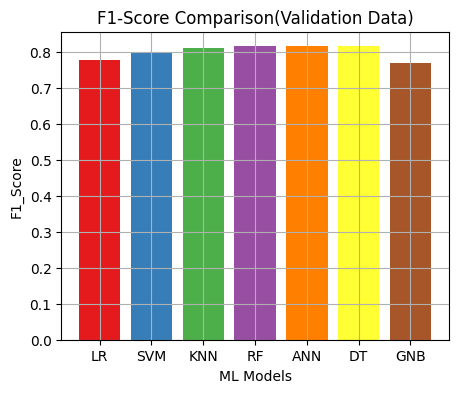

In [811]:
f1 = [f1_lr, f1_svm, f1_knn, f1_rf, f1_mlp, f1_dt, f1_nb]
models = ['LR', 'SVM', 'KNN', 'RF','ANN','DT','GNB']
plt.figure(figsize=(5,4))
colors = plt.cm.Set1(range(len(models)))
plt.bar(models, f1, color=colors)
plt.title('F1-Score Comparison(Validation Data)')
plt.xlabel("ML Models")
plt.ylabel('F1_Score')
plt.grid()
plt.show()

## Model Performance Comparison Table

In [812]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'KNN', 'Random Forest','ANN','Decision Tree','GaussianNB'],
    'Accuracy Train': [accuracy_train_lr,accuracy_train_svm,accuracy_train_knn,accuracy_train_rf,accuracy_train_mlp,accuracy_train_dt,accuracy_train_nb],
    'Accuracy Validation': [accuracy_test_lr,accuracy_test_svm,accuracy_test_knn,accuracy_test_rf,accuracy_test_mlp,accuracy_test_dt,accuracy_test_nb],
    'Precision': [precision_lr,precision_svm,precision_knn,precision_rf,precision_mlp,precision_dt,precision_nb],
    'Recall': [recall_lr,recall_svm,recall_knn,recall_rf,recall_mlp,recall_dt,recall_nb],
    'F1 Score': [f1_lr, f1_svm, f1_knn, f1_rf, f1_mlp, f1_dt, f1_nb]
})
results

,Model,Accuracy Train,Accuracy Validation,Precision,Recall,F1 Score
0,Logistic Regression,0.796348,0.832402,0.815385,0.746479,0.779412
1,SVM,0.825843,0.860335,0.942308,0.690141,0.796748
2,KNN,0.817416,0.865922,0.912281,0.732394,0.812500
3,Random Forest,0.845506,0.871508,0.944444,0.718310,0.816000
4,ANN,0.845506,0.871508,0.944444,0.718310,0.816000
5,Decision Tree,0.845506,0.871508,0.944444,0.718310,0.816000
6,GaussianNB,0.789326,0.832402,0.847458,0.704225,0.769231


# PCA

In [813]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

### Logestic Regression PCA

In [814]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_pca, y_train)

y_pred_train_lr_pca = lr.predict(X_train_pca)
y_pred_test_lr_pca = lr.predict(X_test_pca)

accuracy_train_lr, accuracy_test_lr, precision_lr, recall_lr, f1_lr = evaluation_metrics(y_train, y_pred_train_lr_pca, y_test, y_pred_test_lr_pca)

Accuracy Train: 0.7710674157303371
Accuracy Test: 0.8156424581005587
Precision: 0.7794117647058824
Recall: 0.7464788732394366
F1_Score:0.762589928057554

Confusion_Matrix:
[[93 15]
 [18 53]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       108
           1       0.78      0.75      0.76        71

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [815]:
X_train.shape, X_train_pca.shape

((712, 8), (712, 5))

### KNN

In [816]:
knn = KNeighborsClassifier(n_neighbors= 17, weights='uniform', metric='euclidean')
knn.fit(X_train_pca, y_train)
y_pred_train_knn_pca = knn.predict(X_train_pca)
y_pred_test_knn_pca = knn.predict(X_test_pca)

accuracy_train_knn, accuracy_test_knn, precision_knn, recall_knn, f1_knn = evaluation_metrics(y_train, y_pred_train_knn_pca, y_test, y_pred_test_knn_pca)

Accuracy Train: 0.8033707865168539
Accuracy Test: 0.8379888268156425
Precision: 0.8888888888888888
Recall: 0.676056338028169
F1_Score:0.768

Confusion_Matrix:
[[102   6]
 [ 23  48]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       108
           1       0.89      0.68      0.77        71

    accuracy                           0.84       179
   macro avg       0.85      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179



# SVD

In [817]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=5)

X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

### Logestic Regression SVD

In [818]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_svd, y_train)

y_pred_train_lr_svd = lr.predict(X_train_svd)
y_pred_test_lr_svd = lr.predict(X_test_svd)

accuracy_train_lr, accuracy_test_lr, precision_lr, recall_lr, f1_lr = evaluation_metrics(y_train, y_pred_train_lr_svd, y_test, y_pred_test_lr_svd)

Accuracy Train: 0.7710674157303371
Accuracy Test: 0.8156424581005587
Precision: 0.7794117647058824
Recall: 0.7464788732394366
F1_Score:0.762589928057554

Confusion_Matrix:
[[93 15]
 [18 53]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       108
           1       0.78      0.75      0.76        71

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



### knn pca


In [819]:
knn = KNeighborsClassifier(n_neighbors= 17, weights='uniform', metric='euclidean')
knn.fit(X_train_svd, y_train)

y_pred_train_knn_svd = knn.predict(X_train_svd)
y_pred_test_knn_svd = knn.predict(X_test_svd)

accuracy_train_knn, accuracy_test_knn, precision_knn, recall_knn, f1_knn = evaluation_metrics(y_train, y_pred_train_knn_svd, y_test, y_pred_test_knn_svd)

Accuracy Train: 0.8033707865168539
Accuracy Test: 0.8379888268156425
Precision: 0.8888888888888888
Recall: 0.676056338028169
F1_Score:0.768

Confusion_Matrix:
[[102   6]
 [ 23  48]]

Classification_Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       108
           1       0.89      0.68      0.77        71

    accuracy                           0.84       179
   macro avg       0.85      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179

